In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


In [ ]:
df = pd.read_excel('/content/Daylio_Abid.csv.xlsx')

df['date'] = pd.to_datetime(df['full_date'], format='%d/%m/%Y')

df['mood_clean'] = df['mood'].str.strip().str.lower()

df.head()



,full_date,date,weekday,time,mood,activities,mood_clean
0,2021-04-16,2021-04-16,Friday,20:00:00,yolo,reading | Art | prayer | fasting | walk | med...,yolo
1,2021-04-15,2021-04-15,Thursday,02:37:00,focused,reading | learning | Art | prayer | fasting ...,focused
2,2021-04-14,2021-04-14,Wednesday,02:39:00,confused,reading | learning | prayer | fasting | Qura...,confused
3,2021-04-13,2021-04-13,Tuesday,02:38:00,wondering,reading | learning | Art | prayer | fasting ...,wondering
4,2021-04-12,2021-04-12,Monday,21:52:00,angry,reading | learning | fasting | walk | medita...,angry


In [ ]:
mood_to_score = {
    'over the moon': 5,
    'happiest day': 5,
    'excited': 5,
    'blessed': 5,
    'yolo': 5,
    'cool': 5,
    'chill': 5,
    'good': 5,
    'focused': 4,
    'wondering': 3,
    'confused': 3,
    'meh': 3,
    'hungry': 3,
    'weak': 2,
    'worried': 2,
    'scared': 2,
    'angry': 1,
    'bad': 1,
    'sad af': 1,
    'awful': 1,
    'triggered': 1,
    'sick': 1,
}

df['mood_score'] = df['mood_clean'].map(mood_to_score)

unmapped = df.loc[df['mood_score'].isna(), 'mood_clean'].dropna().unique()

if len(unmapped) > 0:
    print(f"Unmapped moods ({len(unmapped)}):")
    print(unmapped)
else:
    print("All moods are mapped.")

df['mood_score'] = df['mood_score'].fillna(3).astype(float)


All moods are mapped.


In [ ]:
daily = (
    df.groupby('date', as_index=False)
      .agg(
          mood_score=('mood_score', 'mean'),
          weekday=('weekday', 'first'),
          activities=('activities', lambda x: ' | '.join(str(v) for v in x.dropna()))
      )
      .sort_values('date')
)

full_range = pd.date_range(start=daily['date'].min(),
                           end=daily['date'].max(),
                           freq='D')

daily = (
    daily.set_index('date')
         .reindex(full_range)
         .rename_axis('date')
)

daily['mood_score'] = daily['mood_score'].interpolate(limit_direction='both')
daily['weekday'] = daily['weekday'].ffill().bfill()
daily['activities'] = daily['activities'].fillna('no entry')

daily.head()


,mood_score,weekday,activities
date,,,
2018-02-03,2.000000,Saturday,Write dairy | Dota 2 | streaming | shopping ...
2018-02-04,4.333333,Sunday,Write dairy | walk | meditation | Audio book...
2018-02-05,4.333333,Monday,prayer | Watching series | reading | shower |...
2018-02-06,1.666667,Tuesday,Dota 2 | streaming | family | fasting | Dota...
2018-02-07,2.250000,Wednesday,good meal | travel | research | hospital | w...


In [ ]:
daily['day_of_week'] = daily.index.dayofweek
daily['is_weekend'] = (daily['day_of_week'] >= 5).astype(int)

rolling_windows = {
    'mood_3d_avg': 3,
    'mood_7d_avg': 7,
    'mood_30d_avg': 30
}

for col, window in rolling_windows.items():
    daily[col] = daily['mood_score'].rolling(window=window, min_periods=1).mean()

daily['mood_7d_std'] = (
    daily['mood_score']
    .rolling(window=7, min_periods=1)
    .std()
    .fillna(0)
)


In [ ]:
activity_series = (
    daily['activities']
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(' ', '', regex=False)
    .str.split('|')
)

from collections import Counter

activity_counter = Counter([a for acts in activity_series for a in acts if a])
top_activities = [a for a, _ in activity_counter.most_common(10)]

print("Top activities:", top_activities)

for act in top_activities:
    daily[f'act_{act}'] = activity_series.apply(lambda acts: int(act in acts))


Top activities: ['youtube', 'streaming', 'goodmeal', 'audiobooks', 'reddit', 'meditation', 'watchingseries', 'walk', 'newsupdate', 'fasting']


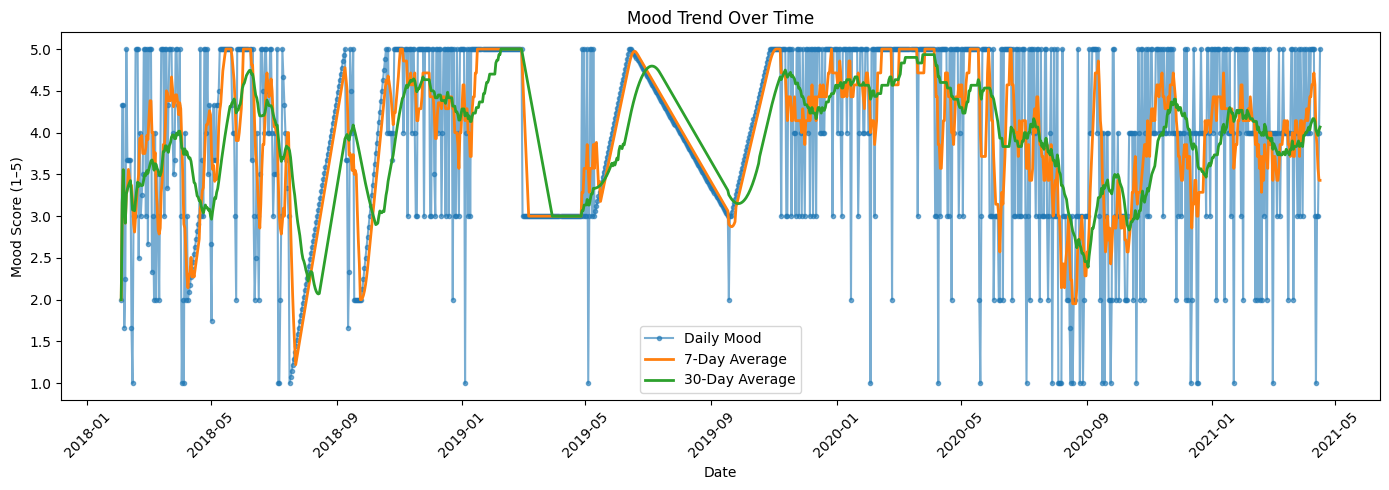

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily.index, daily['mood_score'], marker='.', alpha=0.6, label='Daily Mood')
ax.plot(daily.index, daily['mood_7d_avg'], linewidth=2, label='7-Day Average')
ax.plot(daily.index, daily['mood_30d_avg'], linewidth=2, label='30-Day Average')

ax.set(
    title='Mood Trend Over Time',
    xlabel='Date',
    ylabel='Mood Score (1–5)'
)

ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


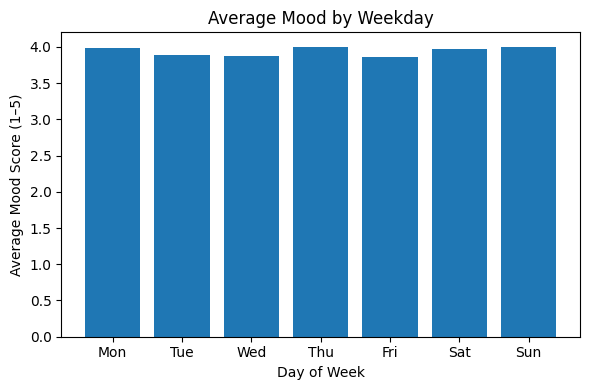

In [ ]:
weekday_mood = daily.groupby('day_of_week')['mood_score'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(weekday_mood.index, weekday_mood.values)

ax.set(
    title='Average Mood by Weekday',
    xlabel='Day of Week',
    ylabel='Average Mood Score (1–5)'
)

ax.set_xticks(range(7))
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()


In [ ]:
activity_cols = [c for c in daily.columns if c.startswith('act_')]

activity_mood = (
    daily[activity_cols]
    .mul(daily['mood_score'], axis=0)
    .replace(0, np.nan)
    .mean()
    .sort_values(ascending=False)
)

activity_mood


,0
act_meditation,4.161351
act_newsupdate,4.086506
act_fasting,4.064601
act_walk,4.059155
act_watchingseries,4.056029
act_audiobooks,4.050341
act_goodmeal,4.049506
act_youtube,4.044630
act_streaming,4.030069
act_reddit,4.029229


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features_for_cluster = ['mood_score', 'mood_7d_avg', 'mood_7d_std', 'is_weekend'] + activity_cols

X_cluster = daily[features_for_cluster].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
daily['mood_cluster'] = kmeans.fit_predict(X_scaled)

daily[['mood_score', 'mood_7d_avg', 'mood_cluster']].head()


,mood_score,mood_7d_avg,mood_cluster
date,,,
2018-02-03,2.000000,2.000000,0
2018-02-04,4.333333,3.166667,2
2018-02-05,4.333333,3.555556,2
2018-02-06,1.666667,3.083333,1
2018-02-07,2.250000,2.916667,2


In [ ]:
features_for_anom = ['mood_score', 'mood_3d_avg', 'mood_7d_avg', 'mood_7d_std', 'is_weekend']

X_anom = daily[features_for_anom].fillna(0)

scaler_anom = StandardScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

iso = IsolationForest(contamination=0.1, random_state=42)
daily['is_anomaly'] = (iso.fit_predict(X_anom_scaled) == -1).astype(int)


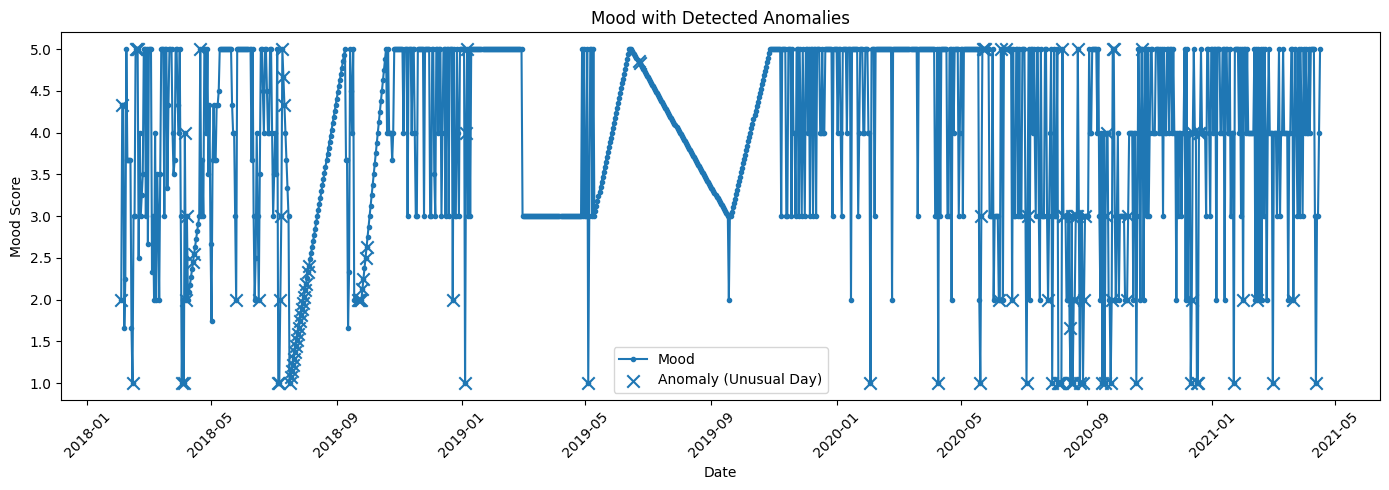

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily.index, daily['mood_score'], marker='.', label='Mood')
anoms = daily[daily['is_anomaly'] == 1]
ax.scatter(anoms.index, anoms['mood_score'], marker='x', s=80, label='Anomaly (Unusual Day)')

ax.set(
    xlabel='Date',
    ylabel='Mood Score',
    title='Mood with Detected Anomalies'
)

ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
LOW_MOOD_THRESHOLD = 2.0

daily['is_low_mood'] = (daily['mood_score'] <= LOW_MOOD_THRESHOLD).astype(int)
daily['low_mood_streak'] = (
    daily['is_low_mood']
    .groupby((daily['is_low_mood'] != daily['is_low_mood'].shift()).cumsum())
    .cumsum()
    * daily['is_low_mood']
)


In [ ]:
def classify_severity(row):
    if row['low_mood_streak'] >= 7 or (row['is_anomaly'] == 1 and row['mood_score'] <= 2):
        return "Critical – please take care and consider reaching out for support"
    elif row['mood_score'] <= 2 or row['is_anomaly'] == 1:
        return "Concerning – reflect on your well-being and try supportive activities"
    elif row['mood_score'] < row['mood_7d_avg']:
        return "Moderate – slight drop in mood compared to recent days"
    else:
        return "Stable – mood appears consistent or improving"

daily['wellbeing_status'] = daily.apply(classify_severity, axis=1)


In [ ]:
print(daily[['mood_score', 'mood_7d_avg', 'is_anomaly', 'low_mood_streak', 'wellbeing_status', 'recommendation']])


            mood_score  mood_7d_avg  is_anomaly  low_mood_streak  \
date                                                               
2018-02-03    2.000000     2.000000           1                1   
2018-02-04    4.333333     3.166667           1                0   
2018-02-05    4.333333     3.555556           0                0   
2018-02-06    1.666667     3.083333           0                1   
2018-02-07    2.250000     2.916667           0                0   
...                ...          ...         ...              ...   
2021-04-12    1.000000     4.000000           1                1   
2021-04-13    3.000000     3.857143           0                0   
2021-04-14    3.000000     3.571429           0                0   
2021-04-15    4.000000     3.428571           0                0   
2021-04-16    5.000000     3.428571           0                0   

                                             wellbeing_status  \
date                                              

In [ ]:
print(daily[['mood_score', 'mood_7d_avg', 'is_anomaly', 'low_mood_streak', 'wellbeing_status', 'recommendation']].tail(10))


            mood_score  mood_7d_avg  is_anomaly  low_mood_streak  \
date                                                               
2021-04-07         5.0     4.428571           0                0   
2021-04-08         5.0     4.571429           0                0   
2021-04-09         5.0     4.571429           0                0   
2021-04-10         5.0     4.714286           0                0   
2021-04-11         3.0     4.571429           0                0   
2021-04-12         1.0     4.000000           1                1   
2021-04-13         3.0     3.857143           0                0   
2021-04-14         3.0     3.571429           0                0   
2021-04-15         4.0     3.428571           0                0   
2021-04-16         5.0     3.428571           0                0   

                                             wellbeing_status  \
date                                                            
2021-04-07      Stable – mood appears consistent or i

In [148]:
!mv /content/drive/MyDrive/Colab Notebooks/Mood_Tracker.ipynb


mv: cannot stat '/content/drive/MyDrive/Colab': No such file or directory


In [149]:
%cd /content/Mental-Health-Mood-Tracker


/content/Mental-Health-Mood-Tracker


In [128]:
!git init


Reinitialized existing Git repository in /content/Mental-Health-Mood-Tracker/.git/


In [129]:
!git remote add origin https://github.com/Hemanth2415/Mental-Health-Mood-Tracker.git


error: remote origin already exists.


In [130]:
!git add .
!git commit -m "Initial commit"


On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)


In [131]:
!git branch -M main


In [141]:
!git push -u origin main

error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Hemanth2415/Mental-Health-Mood-Tracker.git'


In [142]:
!git status


On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)
